In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\project\car_price_dataset_medium.csv')

In [4]:
df

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Volkswagen,2013,143440,Hybrid,Manual,First,3121,558.9,29.45,4,73873.86
996,997,Volkswagen,2021,90436,Electric,Automatic,Third,1295,437.8,10.01,6,115655.85
997,998,Kia,2015,51403,Electric,Manual,Second,4595,274.6,10.38,2,71968.08
998,999,Honda,2011,96170,Petrol,Manual,Third,2948,329.7,12.30,6,58127.19


In [5]:
# EDA
print(df.head())
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

   Car_ID     Brand  Model_Year  Kilometers_Driven Fuel_Type Transmission  \
0       1      Audi        2005             197018    Diesel       Manual   
1       2       BMW        2019              43467    Hybrid    Automatic   
2       3       Kia        2012             153697    Hybrid    Automatic   
3       4  Mercedes        2015              38893    Petrol    Automatic   
4       5      Audi        2016              81329    Hybrid    Automatic   

  Owner_Type  Engine_CC  Max_Power_bhp  Mileage_kmpl  Seats  Price_USD  
0      First       4046          223.6         29.61      6  119611.94  
1      First       3731          248.4         21.66      5   90842.46  
2      Third       4925          465.5         12.14      6   78432.24  
3     Second       3771          229.7         19.65      6   44568.89  
4      First       2817          573.2          7.74      5    8751.82  

Shape: (1000, 12)

Missing Values:
 Car_ID               0
Brand                0
Model_Year      

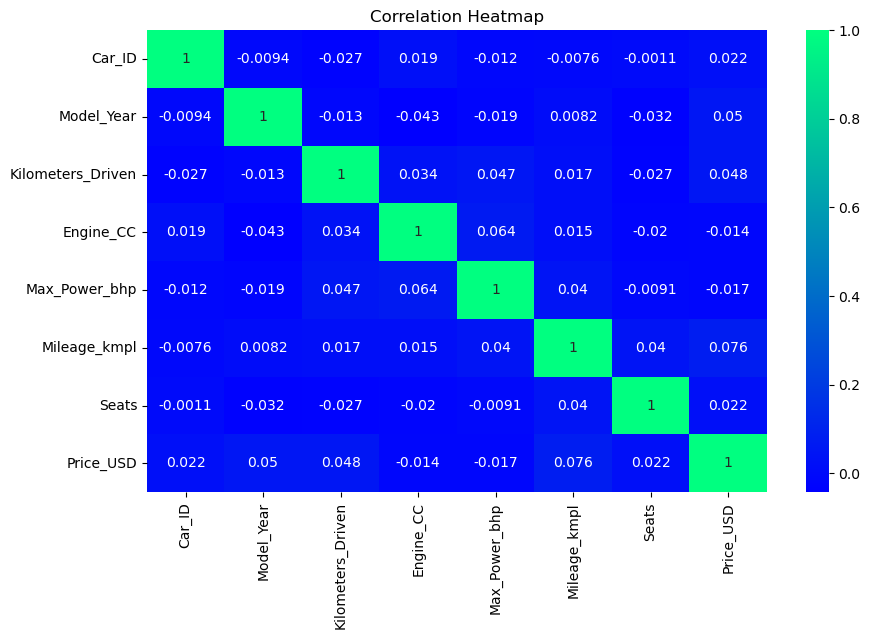

In [19]:
# Visualization

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="winter")
plt.title("Correlation Heatmap")
plt.show()

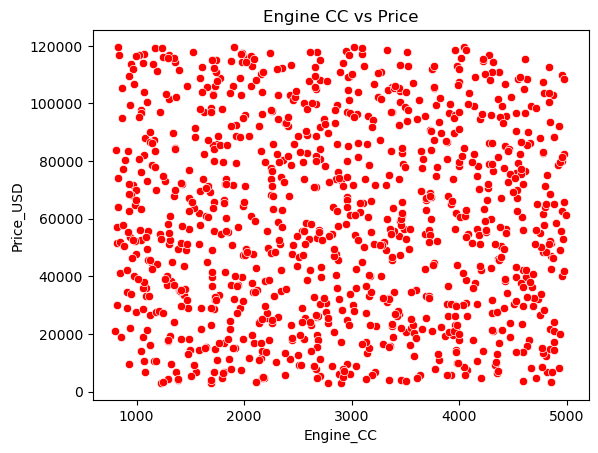

In [26]:
# Scatter Plot: Engine vs Price
sns.scatterplot(x="Engine_CC", y="Price_USD", data=df, color="red")
plt.title("Engine CC vs Price")
plt.show()

In [22]:
# Feature Selection (Numeric Only for Simple Model)
X = df[["Engine_CC", "Max_Power_bhp", "Kilometers_Driven"]]
y = df["Price_USD"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Import the necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
X = np.random.rand(100, 1) 
y = 2 * X + 1 + 0.1 * np.random.randn(100, 1)  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [6]:

from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.963301812882717


In [35]:
import numpy as np
from sklearn.metrics import mean_squared_error

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression RMSE: 33980.561937917984


In [37]:
# Import the Lasso class from scikit-learn
from sklearn.linear_model import Lasso

# Lasso Regression (L1 Regularization)
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [42]:
import numpy as np

print("\nLasso Regression (L1) R2:", r2_score(y_test, y_pred_lasso))
# Calculate RMSE manually by taking the square root of MSE
print("Lasso Regression (L1) RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))


Lasso Regression (L1) R2: -0.03384361894413179
Lasso Regression (L1) RMSE: 33980.56154796776


In [7]:
# Import the Ridge class from scikit-learn
from sklearn.linear_model import Ridge

# Now we can use the Ridge class
ridge = Ridge(alpha=0.5)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [8]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Calculate R2 score
print("\nRidge Regression (L2) R2:", r2_score(y_test, y_pred_ridge))

# Calculate RMSE manually by taking the square root of MSE
print("Ridge Regression (L2) RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Ridge Regression (L2) R2: 0.9746832992560893
Ridge Regression (L2) RMSE: 0.08891990931452681


In [12]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# Initialize the models
lr = LinearRegression()
lasso = Lasso(alpha=0.1)  # Initialize Lasso with an alpha value
ridge = Ridge(alpha=0.1)  # Initialize Ridge with an alpha value

lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Compare Coefficient
print("\nCoefficients Comparison:")
print("Linear Regression Coeff:", lr.coef_)
print("Lasso Coeff:", lasso.coef_)
print("Ridge Coeff:", ridge.coef_)


Coefficients Comparison:
Linear Regression Coeff: [[2.05570077]]
Lasso Coeff: [0.73266835]
Ridge Coeff: [2.02225688]
